<a href="https://colab.research.google.com/github/mihapronin/ABC-PLO-Classification/blob/main/ABC_PLO_PWLF_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Explainable K-class ABC segmentation with PWLF + Elbow (UCI Online Retail)

This notebook builds **data-driven ABC classes with an arbitrary number of tiers (K)** by approximating the **cumulative Pareto curve** with a **piecewise-linear model (PWLF)**.

What you get:
- **Hero plot**: Pareto curve with K segments, shaded class regions, and chords (average density per class)
- **Class table**: SKU share, value share, and **density vs. catalog average** (`value_share / sku_share`)
- **Elbow plot**: a simple, explainable way to pick **K** as a trade-off between simplicity and fit

## Dataset
https://archive.ics.uci.edu/dataset/352/online+retail  

UCI *Online Retail* (`Online Retail.xlsx`). Each transaction line has `StockCode` (SKU), `Quantity`, and `UnitPrice`.

## Value metric (classic “dollar usage”)
We compute SKU value as line revenue aggregated by SKU:

$$\text{value}_{\text{sku}} = \sum (\text{Quantity} \times \text{UnitPrice})$$

> Cleaning note: we remove cancellations and keep only strictly positive `Quantity` and `UnitPrice` (gross positive-sales view).


## How to run

- Download `Online Retail.xlsx` from the UCI dataset page and place it where your runtime can access it.
- Update `DATA_PATH` in the next cell.

If you run this outside Colab, replace the `!pip install` line with your environment’s package installation flow.


In [ ]:
# Setup and data loading

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install -q pwlf
import pwlf

# Path to the UCI Online Retail dataset
DATA_PATH = "/content/drive/MyDrive/Projects/publications/data/UCI_Online_Retail/Online Retail.xlsx"

if not os.path.exists(DATA_PATH):
    # Raise error if file not found
    raise FileNotFoundError(f"File not found at {DATA_PATH}. Please check the path.")

print(f"Loading dataset from {DATA_PATH}...")
# Loading Excel can take a moment
df = pd.read_excel(DATA_PATH, dtype={'InvoiceNo': str, 'CustomerID': str})
print("Data loaded successfully.")

display(df.head())

Loading dataset from /content/drive/MyDrive/Projects/publications/data/UCI_Online_Retail/Online Retail.xlsx...
Data loaded successfully.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## Core definitions for the ABC segmentation logic

This section defines ABC segmentation logic functions used later:

- Data Prep: `build_value_per_sku_retail`
- Pareto Math: `pareto_curve`, `downsample_curve`
- Optimization: `sweep_K_pwlf`, `calculate_elbow_distance`, `fit_pwlf_segments_constrained`
- Segmentation Logic: `segs_to_rank_cuts`, `snap_cuts_to_values`, `cuts_to_segments`
- Reporting & Viz: `class_table_from_curve`, `plot_segments_on_full`

Here we only define the building blocks.


In [ ]:
# @title Core Segmentation & Analysis Functions
"""
Core definitions for the ABC segmentation logic.

Includes:
1. Data Prep: `build_value_per_sku_retail`
2. Pareto Math: `pareto_curve`, `downsample_curve`
3. Optimization: `sweep_K_pwlf`, `calculate_elbow_distance`, `fit_pwlf_segments_constrained`
4. Segmentation Logic: `segs_to_rank_cuts`, `snap_cuts_to_values`, `cuts_to_segments`
5. Reporting & Viz: `class_table_from_curve`, `plot_segments_on_full`
"""

def build_value_per_sku_retail(df: pd.DataFrame) -> pd.Series:
    """
    Cleans raw retail data and computes total value per SKU.

    Args:
        df (pd.DataFrame): Raw transaction dataframe.

    Returns:
        pd.Series: Total value indexed by StockCode, sorted descending.
    """
    # Remove cancellations (InvoiceNo starting with 'C')
    clean = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

    # Remove negative/zero quantities and prices
    clean = clean[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]

    # Calculate line value
    clean["Value"] = clean["Quantity"] * clean["UnitPrice"]

    # Aggregate by StockCode to get total value per item
    out = clean.groupby("StockCode")["Value"].sum()

    out = out.sort_values(ascending=False)
    return out

def pareto_curve(values_desc: pd.Series):
    """
    Computes the cumulative Pareto curve coordinates (x, y).

    Args:
        values_desc (pd.Series): SKU values sorted in descending order.

    Returns:
        tuple: (x, y) arrays representing SKU share and cumulative value share.
    """
    v = values_desc.values.astype(float)
    N = len(v)
    x = np.arange(1, N+1) / N
    y = np.cumsum(v) / v.sum()
    return x, y

def downsample_curve(x: np.ndarray, y: np.ndarray, max_points: int = 1500):
    """
    Downsamples the curve to a maximum number of points for performance.

    Args:
        x (np.ndarray): X coordinates (0..1).
        y (np.ndarray): Y coordinates (0..1).
        max_points (int): Maximum number of points to keep.

    Returns:
        tuple: (indices, downsampled_x, downsampled_y).
    """
    N = len(x)
    if N <= max_points:
        idx = np.arange(N)
        return idx, x, y
    step = int(np.ceil(N / max_points))
    idx = np.unique(np.r_[np.arange(step-1, N, step), N-1])
    return idx, x[idx], y[idx]

def calculate_elbow_distance(df):
    """
    Calculates the geometric distance from each point to the line connecting start and end points (Elbow method).

    Args:
        df (pd.DataFrame): DataFrame with columns 'K' and 'SSE'.

    Returns:
        pd.DataFrame: DataFrame with an added 'distance_to_diag' column.
    """
    df = df.copy()
    x = df["K"].values
    y = df["SSE"].values
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    numerator = np.abs((p2[1] - p1[1]) * x - (p2[0] - p1[0]) * y + p2[0] * p1[1] - p2[1] * p1[0])
    denominator = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2)
    df["distance_to_diag"] = numerator / denominator
    return df

def segs_to_rank_cuts(x_ds: np.ndarray, segs_ds, N_full: int):
    """
    Maps segment boundaries from downsampled space to full ranking indices.

    Args:
        x_ds (np.ndarray): Downsampled X coordinates.
        segs_ds (list): List of segment tuples (start_idx, end_idx) in downsampled space.
        N_full (int): Total number of SKUs in the full dataset.

    Returns:
        list: List of rank indices (1..N) where splits occur.
    """
    # Breakpoints are starts of segments beyond the first
    cuts = []
    for (a, b) in segs_ds[1:]:
        x_break = x_ds[a-1]  # start x of that segment in cumulative space
        cut = int(np.ceil(x_break * N_full))  # 1..N
        cuts.append(cut)
    return cuts

def cuts_to_segments(cuts, N):
    """
    Converts cut ranks into inclusive segment index ranges (0..N-1).

    Args:
        cuts (list): List of rank indices where splits occur.
        N (int): Total number of items.

    Returns:
        list: List of tuples (start_idx, end_idx) for each segment.
    """
    # cuts are ranks (1..N) where new segment starts; convert to 0-index inclusive segments
    cuts_sorted = sorted([c for c in cuts if 1 < c <= N])
    segs = []
    start = 0
    for c in cuts_sorted:
        end = c-2  # previous rank
        if end >= start:
            segs.append((start, end))
        start = c-1
    segs.append((start, N-1))
    return segs

def class_table_from_curve(values_desc: pd.Series, segs):
    """
    Generates a summary table of ABC classes based on curve segments.

    Args:
        values_desc (pd.Series): SKU values sorted descending.
        segs (list): List of (start, end) indices for each class.

    Returns:
        pd.DataFrame: Table with class metrics (share, value, density).
    """
    v = values_desc.values.astype(float)
    N = len(v)
    x = np.arange(1, N+1) / N
    y = np.cumsum(v) / v.sum()

    rows = []
    for i, (a, b) in enumerate(segs, start=1):
        x0 = x[a-1] if a > 0 else 0.0
        y0 = y[a-1] if a > 0 else 0.0
        x1 = x[b]
        y1 = y[b]
        sku_share = x1 - x0
        val_share = y1 - y0
        density = val_share / sku_share if sku_share > 0 else np.nan
        rows.append({
            "class": chr(64 + i),  # Generates A, B, C...
            "rank_from": a+1,
            "rank_to": b+1,
            "sku_count": b-a+1,
            "sku_share": sku_share,
            "value_share": val_share,
            "density_vs_avg": density
        })
    return pd.DataFrame(rows)

def plot_segments_on_full(values_desc: pd.Series, segs, title, cmap_name="Dark2", save_path=None):
    """
    Plots the cumulative Pareto curve with highlighted segments and chords.

    Args:
        values_desc (pd.Series): SKU values sorted descending.
        segs (list): List of (start, end) indices for segments.
        title (str): Plot title.
        cmap_name (str): Name of the matplotlib colormap to use (default: "Set3").
        save_path (str, optional): File path to save the plot. If None, plot is not saved.
    """
    v = values_desc.values.astype(float)
    N = len(v)
    x = np.arange(1, N+1) / N
    y = np.cumsum(v) / v.sum()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y, label="Cumulative curve")

    # Shaded class regions + matching chord colors
    K = len(segs)

    # Get colormap, falling back to Set3 if invalid
    try:
        cmap = plt.get_cmap(cmap_name)
    except ValueError:
        cmap = plt.get_cmap("Set3")

    colors = cmap(np.linspace(0, 1, max(K, 3)))[:K]

    for i, (a, b) in enumerate(segs):
        x0 = x[a-1] if a > 0 else 0.0
        y0 = y[a-1] if a > 0 else 0.0
        x1 = x[b]
        y1 = y[b]

        # Background region (helps visually read class boundaries)
        ax.axvspan(x0, x1, color=colors[i], alpha=0.18, linewidth=0)

        # Chord for the segment (average density = Δy/Δx)
        # Use A, B, C... naming
        class_name = chr(65 + i)
        ax.plot([x0, x1], [y0, y1], linewidth=3, color=colors[i], label=f"Class {class_name}")

        # Boundary marker (except for the very first segment)
        if a > 0:
            ax.axvline(x0, linestyle="--", alpha=0.6, color="gray", linewidth=1)

    ax.set_xlabel("Share of SKUs (sorted by value)")
    ax.set_ylabel("Cumulative share of value")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Keep legend compact for larger K
    if K <= 6:
        ax.legend(loc="lower right")
    else:
        ax.legend(loc="lower right", ncol=2, fontsize=9)

    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")

    plt.show()

def fit_pwlf_segments_constrained(x_ds, y_ds, K):
    """
    Fits a continuous piecewise linear function and snaps breakpoints to valid indices.

    Args:
        x_ds (np.ndarray): Downsampled X coordinates.
        y_ds (np.ndarray): Downsampled Y coordinates.
        K (int): Number of segments.

    Returns:
        list: List of (start, end) indices for the fitted segments.
    """
    # Fit continuous model
    # x_ds and y_ds should be strictly increasing/valid for pwlf usually
    model = pwlf.PiecewiseLinFit(x_ds, y_ds)

    # fit(K) returns K+1 breakpoints: [x0, x1, ..., xK]
    breaks = model.fit(K)

    # Map continuous breakpoints to discrete indices in x_ds
    # We only need the internal breakpoints x1...x(K-1)
    internal_breaks = breaks[1:-1]

    cut_indices = []
    for b in internal_breaks:
        # Find closest index in x_ds
        idx = np.abs(x_ds - b).argmin()
        cut_indices.append(idx)

    # Sort and remove duplicates just in case
    cut_indices = sorted(list(set(cut_indices)))

    # Form segments [(start, end), ...] corresponding to indices in x_ds
    segs = []
    start = 0
    N_ds = len(x_ds)

    for c in cut_indices:
        # Avoid zero-length segments if possible (end >= start)
        end = max(start, c)
        segs.append((start, end))
        start = end + 1

    # Final segment
    segs.append((start, N_ds - 1))

    return segs

def snap_cuts_to_values(cuts, values):
    """
    Adjusts cut ranks so that items with identical values are kept in the same class.

    Args:
        cuts (list): List of proposed rank cuts.
        values (pd.Series): Full series of SKU values (descending).

    Returns:
        list: Adjusted list of rank cuts.
    """
    v = values.values
    N = len(v)
    adjusted_cuts = []

    for c in cuts:
        # valid cut is 1..N-1
        if c < 1 or c >= N:
            adjusted_cuts.append(c)
            continue

        # Check if splitting ties:
        # value at rank c (index c-1) == value at rank c+1 (index c)
        # We assume descending sort.
        current_idx = c
        while current_idx < N and v[current_idx-1] == v[current_idx]:
            current_idx += 1

        adjusted_cuts.append(current_idx)

    return adjusted_cuts

def sweep_K_pwlf(x, y, max_K=10):
    """
    Sweeps K from 2 to max_K, fitting a PWLF model for each to calculate SSE.

    Args:
        x (np.ndarray): X coordinates.
        y (np.ndarray): Y coordinates.
        max_K (int): Maximum number of segments to test.

    Returns:
        pd.DataFrame: DataFrame with 'K' and 'SSE' for each iteration.
    """
    out = []
    # Initialize PWLF model
    model = pwlf.PiecewiseLinFit(x, y)
    for k_curr in range(2, max_K+1):
        print(f"Fitting PWLF for K={k_curr}...")
        # optimization: reduce popsize (speed up) and tolerance
        # default popsize is 15, reducing to 3 makes it ~5x faster
        model.fit(k_curr, popsize=3, tol=0.01, seed=42)
        out.append((k_curr, model.ssr))
    return pd.DataFrame(out, columns=["K", "SSE"])

def fixed_threshold_segments(values_desc: pd.Series, targets=(0.80, 0.95, 1.00)):
    v = values_desc.values.astype(float)
    N = len(v)
    y = np.cumsum(v) / v.sum()
    cuts = [int(np.searchsorted(y, t, side="left")) for t in targets]
    segs=[]
    start=0
    for c in cuts:
        end=min(c, N-1)
        if end >= start:
            segs.append((start, end))
        start=end+1
        if start>=N:
            break
    return segs

## Compute value per SKU (metric + cleaning)

We compute SKU value from transaction lines:

1) Remove cancellations (`InvoiceNo` starts with `'C'`)
2) Keep only `Quantity > 0` and `UnitPrice > 0`
3) Line value: `Value = Quantity * UnitPrice`
4) Aggregate by `StockCode` and sort descending

**Interpretation:** a *gross positive-sales* view (returns/credits are excluded by filters).


In [ ]:
values = build_value_per_sku_retail(df)
display(values.head())
print("Number of SKUs:", values.shape[0])

,Value
StockCode,
DOT,206248.77
22423,174484.74
23843,168469.60
85123A,104518.80
47566,99504.33


Number of SKUs: 3922


## Build the cumulative Pareto curve

- **x**: share of SKUs (`rank / N`) after sorting SKUs by value (descending)
- **y**: cumulative share of total value

Both axes are normalized to \([0,1]\). The curve starts at \(x=1/N\); when we compute segment shares we treat the origin as \((0,0)\).


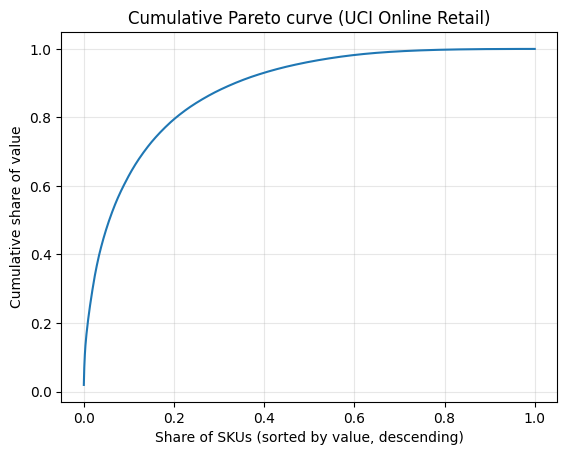

In [ ]:
x, y = pareto_curve(values)

plt.figure()
plt.plot(x, y)
plt.xlabel("Share of SKUs (sorted by value, descending)")
plt.ylabel("Cumulative share of value")
plt.title("Cumulative Pareto curve (UCI Online Retail)")
plt.grid(True, alpha=0.3)
plt.savefig("Bare_Pareto_curve.png")
plt.show()

### Downsampling for speed

PWLF fitting can be slow on very large catalogs. We downsample the \((x,y)\) curve to at most ~1500 points **only for fitting and K selection**.

All business outputs (class table, density KPI, hero plot) are computed on the **full** SKU ranking after mapping the breakpoints back.


In [ ]:
idx_ds, x_ds, y_ds = downsample_curve(x, y, max_points=1500)
len(x), len(x_ds)


(3922, 1308)

## Choosing K: SSE elbow on the downsampled curve

We sweep **K = 2..10**. For each K we fit PWLF on the downsampled curve and record **SSE**.
Then we pick the **elbow** as the point with the maximum geometric distance to the straight line connecting:
- the first point (smallest K) and
- the last point (largest K)

Interpretation: increasing K always improves fit, but after the elbow the gains are marginal.


Note: we use the downsampled curve only to select `optimal_k` quickly; the final class boundaries are mapped back to the full SKU ranking in the next step.



Sweeping K (2..10) using PWLF (fast mode) to find elbow...
Fitting PWLF for K=2...
Fitting PWLF for K=3...
Fitting PWLF for K=4...
Fitting PWLF for K=5...
Fitting PWLF for K=6...
Fitting PWLF for K=7...
Fitting PWLF for K=8...
Fitting PWLF for K=9...
Fitting PWLF for K=10...


,SSE,distance_to_diag
K,,
2,1.459067,0.000000
3,0.346350,0.915713
4,0.111060,0.968174
5,0.047411,0.851767
6,0.024104,0.695670
7,0.014145,0.526442
8,0.008267,0.353197
9,0.004910,0.177472
10,0.003329,0.000000


Optimal K (PWLF) selected: 4


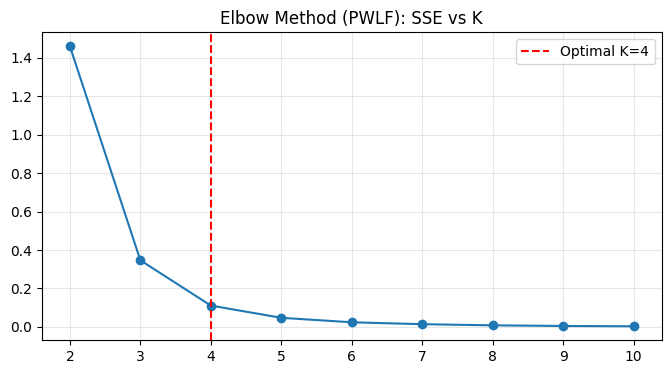

Refining fit for optimal K=4...
Final Segmentation Error (SSE) with K=4: 0.111085


In [ ]:
# Optimization Logic: Find Optimal K for PWLF

print("Sweeping K (2..10) using PWLF (fast mode) to find elbow...")
sweep_pwlf = sweep_K_pwlf(x_ds, y_ds, max_K=10)

# Calculate elbow distance to find the optimal K
sweep_metrics_pwlf = calculate_elbow_distance(sweep_pwlf)

optimal_idx_pwlf = sweep_metrics_pwlf["distance_to_diag"].idxmax()
optimal_K_pwlf = int(sweep_metrics_pwlf.loc[optimal_idx_pwlf, "K"])

# Show decision
# Highlight the entire row corresponding to the optimal K
display(sweep_metrics_pwlf.set_index('K').style.apply(
    lambda x: ['background-color: darkgreen' if x.name == optimal_K_pwlf else '' for _ in x],
    axis=1
))
print(f"Optimal K (PWLF) selected: {optimal_K_pwlf}")

plt.figure(figsize=(8, 4))
plt.plot(sweep_metrics_pwlf["K"], sweep_metrics_pwlf["SSE"], marker="o")
plt.axvline(optimal_K_pwlf, color="red", linestyle="--", label=f"Optimal K={optimal_K_pwlf}")
plt.title("Elbow Method (PWLF): SSE vs K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Elbow_Method.png")
plt.show()

# Final Check with Optimal K (PWLF)
# We perform a higher quality fit for the final chosen K
print(f"Refining fit for optimal K={optimal_K_pwlf}...")
model_final = pwlf.PiecewiseLinFit(x_ds, y_ds)
breaks_final = model_final.fit(optimal_K_pwlf, popsize=10, seed=42)
err_final = model_final.ssr
print(f"Final Segmentation Error (SSE) with K={optimal_K_pwlf}: {err_final:.6f}")

## Final Segmentation (PWLF)

Now we build the final **K-class ABC** segmentation.

**Inputs**
- Full Pareto curve `(x, y)` built from the complete SKU ranking.
- `optimal_k` chosen on the downsampled curve (previous step).

**What happens in this step**
1) **Fit PWLF with K segments** (for speed we can fit on the downsampled curve, but the segmentation is applied to the *full* SKU list).
2) **Map PWLF breakpoints to the full SKU ranking**:
   - each breakpoint `x` (share of SKUs) becomes a **rank cutoff** in the full sorted list.
3) **Snap boundaries to ties**:
   - if multiple SKUs share the same value around a cutoff, we move the boundary to avoid splitting equal-value items across classes.
4) **Build the class table + density KPI**:
   - `sku_share` = % of total SKUs
   - `value_share` = % of total value
   - `density_vs_avg = value_share / sku_share`
   - interpretation: `density_vs_avg > 1` means the class is more value-concentrated than average.
5) **Visual summary**:
   - Pareto curve with class boundaries and chords (average density per class).

**Outputs**
- `segs_rank`: final rank cutoffs on the full list
- `class_table`: per-class KPI summary
- plots for a quick sanity-check



Fitting PWLF approximation with K=4...


,rank_from,rank_to,sku_count,sku_share,value_share,density_vs_avg
class,,,,,,
A,1,194,194,4.9%,47.2%,9.54x
B,195,716,522,13.3%,30.2%,2.27x
C,717,1796,1080,27.5%,17.7%,0.64x
D,1797,3922,2126,54.2%,4.9%,0.09x


Plot saved to Final_Segmentation


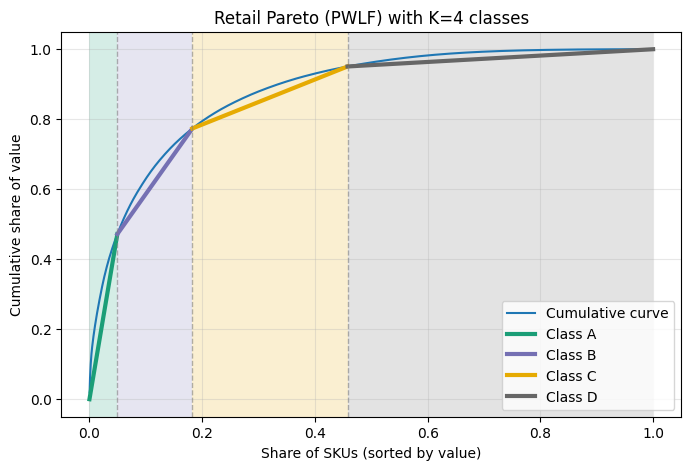

In [ ]:
# 1. Fit using pwlf with the same Optimal K found earlier
print(f"Fitting PWLF approximation with K={optimal_K_pwlf}...")
segs_pwlf_ds = fit_pwlf_segments_constrained(x_ds, y_ds, K=optimal_K_pwlf)

# 2. Map breakpoints from downsampled curve back to full ranking
cuts_pwlf = segs_to_rank_cuts(x_ds, segs_pwlf_ds, N_full=len(values))

# 3. Enforce "same contribution" constraint (don't split ties)
cuts_pwlf_snapped = snap_cuts_to_values(cuts_pwlf, values)

# 4. Convert to full segments
segs_pwlf_full = cuts_to_segments(cuts_pwlf_snapped, N=len(values))

# 5. Display table
tbl_pwlf = class_table_from_curve(values, segs_pwlf_full)
display(tbl_pwlf.set_index('class').style.format({
    "sku_share": "{:.1%}",
    "value_share": "{:.1%}",
    "density_vs_avg": "{:.2f}x"
}))

# 6. Plot
plot_segments_on_full(values, segs_pwlf_full, title=f"Retail Pareto (PWLF) with K={optimal_K_pwlf} classes")

# Alias for downstream cells
tbl = tbl_pwlf.copy()

## Why piecewise-linear segments are business-interpretable

On the Pareto curve:
- \(x\) = SKU share
- \(y\) = cumulative value share

For a class covering \([x_0, x_1]\) on the curve, its **average density** is the chord slope:

$$
\text{density} = \frac{\Delta y}{\Delta x} = \frac{\text{Segment Value Share}}{\text{Segment SKU Share}}
$$

Because both axes are normalized, **density reads as “value per SKU vs. catalog average.”**
That makes each class a natural **policy tier** (review cadence, service target, cycle counting frequency, etc.).


### Quick sanity-checks

Two small charts to validate the segmentation:
- **value_share by class** (should be strictly decreasing)
- **density_vs_avg by class** (a compact view of value concentration)

These are optional, but they help when you compare different K or different value definitions.


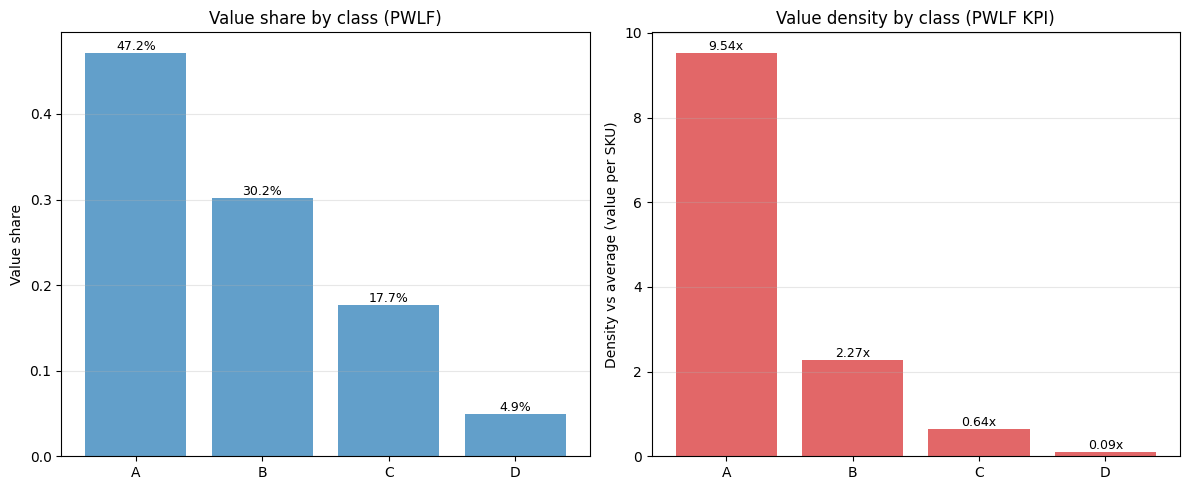

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Value share by class
ax = axes[0]
ax.bar(tbl_pwlf["class"], tbl_pwlf["value_share"], color="tab:blue", alpha=0.7)
ax.set_ylabel("Value share")
ax.set_title("Value share by class (PWLF)")
ax.grid(True, axis="y", alpha=0.3)
# Add labels
for i, v in enumerate(tbl_pwlf["value_share"]):
    ax.text(i, v, f"{v:.1%}", ha='center', va='bottom', fontsize=9)

# Plot 2: Value density by class
ax = axes[1]
ax.bar(tbl_pwlf["class"], tbl_pwlf["density_vs_avg"], color="tab:red", alpha=0.7)
ax.set_ylabel("Density vs average (value per SKU)")
ax.set_title("Value density by class (PWLF KPI)")
ax.grid(True, axis="y", alpha=0.3)
# Add labels
for i, v in enumerate(tbl_pwlf["density_vs_avg"]):
    ax.text(i, v, f"{v:.2f}x", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("Value_Share_and_Density.png")
plt.show()

## Baseline: classic fixed 80/95/100% ABC

This baseline uses fixed cumulative value targets (80%, 95%, 100%).
It is useful to show why fixed thresholds can mismatch the actual curve shape when you want more explainable boundaries or a different number of tiers.


In [ ]:
abc_segs = fixed_threshold_segments(values, targets=(0.80, 0.95, 1.00))
abc_tbl = class_table_from_curve(values, abc_segs)

display(abc_tbl.set_index('class').style.format({
    "sku_share": "{:.1%}",
    "value_share": "{:.1%}",
    "density_vs_avg": "{:.2f}x"
}))


,rank_from,rank_to,sku_count,sku_share,value_share,density_vs_avg
class,,,,,,
A,1,804,804,20.5%,80.0%,3.90x
B,805,1787,983,25.1%,15.0%,0.60x
C,1788,3922,2135,54.4%,5.0%,0.09x


Plot saved to Fixed_Thresholds.png


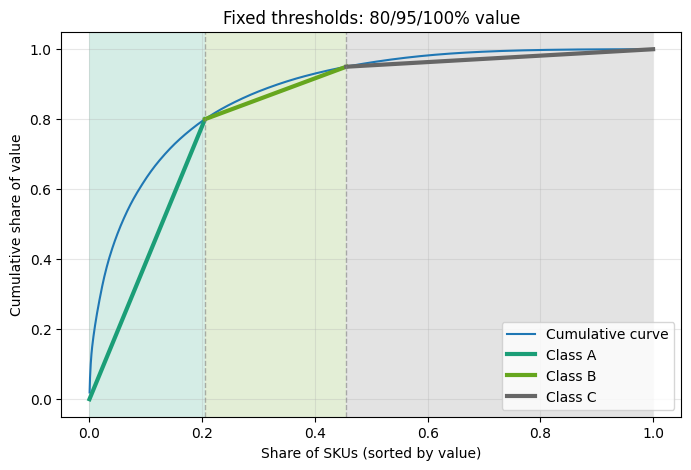

In [ ]:
plot_segments_on_full(values, abc_segs, title="Fixed thresholds: 80/95/100% value")

## Policy mapping (example)

Turn the class table into operational tiers.

Below is a *toy* mapping (illustrative only) that attaches example parameters (review cadence, cycle count frequency) to each class.
Replace it with your organization’s real policy parameters.


In [ ]:
# Ensure class_name exists for downstream compatibility (policy merge)
tbl["class_name"] = tbl["class"]

# Example policy mapping: adjust to your business
policy = pd.DataFrame({
    "class_name": [chr(65+i) for i in range(len(tbl))], # Generates A, B, C, D...
    "review_cadence_days": [7, 14, 21, 30, 45][:len(tbl)],
    "cycle_count_per_year": [12, 6, 4, 2, 1][:len(tbl)],
})

# Merge using the class_name column
final_table = tbl.merge(policy, on="class_name", how="left")

# Select and reorder columns for the final report
report_cols = ["class", "sku_count", "sku_share", "value_share", "density_vs_avg", "review_cadence_days", "cycle_count_per_year"]
report_cols = ["class", "sku_count", "sku_share", "value_share", "density_vs_avg", "review_cadence_days", "cycle_count_per_year"]

print("Operational Segmentation Table (ABCD Naming):")
display(final_table[report_cols].set_index('class_name').style.format({
    "sku_share": "{:.1%}",
    "value_share": "{:.1%}",
    "density_vs_avg": "{:.2f}x"
}))

Operational Segmentation Table (ABCD Naming):


,sku_count,sku_share,value_share,density_vs_avg,review_cadence_days,cycle_count_per_year
class_name,,,,,,
A,194,4.9%,47.2%,9.54x,7,12
B,522,13.3%,30.2%,2.27x,14,6
C,1080,27.5%,17.7%,0.64x,21,4
D,2126,54.2%,4.9%,0.09x,30,2


In [ ]:
report_cols_1 = ["class", "rank_from", "rank_to", "sku_count", "sku_share", "value_share", "density_vs_avg"]

print("Segmentation Table (ABCD Naming):")
display(final_table[report_cols_1].set_index('class').style.format({
    "sku_share": "{:.1%}",
    "value_share": "{:.1%}",
    "density_vs_avg": "{:.2f}x"
}))

Operational Segmentation Table (ABCD Naming):


,rank_from,rank_to,sku_count,sku_share,value_share,density_vs_avg
class,,,,,,
A,1,194,194,4.9%,47.2%,9.54x
B,195,716,522,13.3%,30.2%,2.27x
C,717,1796,1080,27.5%,17.7%,0.64x
D,1797,3922,2126,54.2%,4.9%,0.09x


## Next steps

To adapt this notebook to a real inventory environment:

- **Change the value metric** (revenue, margin, cost, contribution, or demand volume).
- Choose the **segmentation grain** (often `location × SKU`).
- Decide how to treat **returns/cancellations** (gross vs. net).
- Replace the toy **policy mapping** with your real replenishment / counting / service parameters per class.

The key deliverable to stakeholders is usually the **hero plot + class table**.
